<a href="https://colab.research.google.com/github/adanbintewaqar/decode-labs-project-1/blob/main/Project_1_Advanced_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# 1. LOAD THE DATASET
file_path = 'Dataset for Data Analytics - Sheet1.csv'
df = pd.read_csv(file_path)

print(f"Original Dataset Shape: {df.shape}\n")

# ---------------------------------------------------------
# STAGE 1: INPUT FIDELITY & DATA CLEANING
# ---------------------------------------------------------
# A. Missing Value Imputation
# CouponCode has 25.75% missingness (>20% threshold) -> Impute with 'NO_COUPON'
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

# B. Outlier Neutralization (IQR Method + Winsorization/Clipping)
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap extreme values at lower/upper statistical boundaries
    df[col] = np.clip(df[col], lower_bound, upper_bound)

print("✅ Stage 1 Complete: Missing values imputed and outliers capped.")

# ---------------------------------------------------------
# STAGE 2: FEATURE ENGINEERING & COMPUTATION
# ---------------------------------------------------------
# Feature 1: Has_Coupon (Binary Indicator)
df['Has_Coupon'] = np.where(df['CouponCode'] == 'NO_COUPON', 0, 1)

# Feature 2: Is_Weekend (Extracted from Date)
df['Date'] = pd.to_datetime(df['Date'])
df['Order_Month'] = df['Date'].dt.month
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)

# Feature 3: AvgPricePerCartItem
df['AvgPricePerCartItem'] = df['TotalPrice'] / df['ItemsInCart']

# Feature 4: QuantityToCartRatio
df['QuantityToCartRatio'] = df['Quantity'] / df['ItemsInCart']

# Convert Categorical Columns to Coordinate Space (One-Hot Encoding)
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("✅ Stage 2 Complete: Engineered 4 predictive features & one-hot encoded categories.")

# ---------------------------------------------------------
# STAGE 3: RUNTIME DATA VALIDATION & EXPORT
# ---------------------------------------------------------
# Verify data contracts
assert df_encoded.isnull().sum().sum() == 0, "Validation Error: Null values found!"
assert (df_encoded['TotalPrice'] >= 0).all(), "Validation Error: Negative prices found!"

# Save processed output
output_file = 'Cleaned_Data_Analytics_Dataset.csv'
df_encoded.to_csv(output_file, index=False)

print(f"✅ Stage 3 Complete: Runtime checks passed. Clean dataset exported as '{output_file}'.\n")
print("--- PREVIEW OF CLEANED DATASET ---")
display(df_encoded.head())

Original Dataset Shape: (1200, 14)

✅ Stage 1 Complete: Missing values imputed and outliers capped.
✅ Stage 2 Complete: Engineered 4 predictive features & one-hot encoded categories.
✅ Stage 3 Complete: Runtime checks passed. Clean dataset exported as 'Cleaned_Data_Analytics_Dataset.csv'.

--- PREVIEW OF CLEANED DATASET ---


,OrderID,Date,CustomerID,Quantity,UnitPrice,ShippingAddress,TrackingNumber,ItemsInCart,CouponCode,TotalPrice,...,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,ORD200000,2023-01-04,C72649,5,570.62,928 Main St,TRK37947903,7,SAVE10,2853.10,...,False,False,False,False,False,True,False,False,True,False
1,ORD200001,2024-08-23,C75739,2,151.35,823 Main St,TRK91186779,3,SAVE10,302.70,...,False,True,False,False,False,True,False,False,False,True
2,ORD200002,2024-02-27,C81728,5,550.68,512 Main St,TRK42903982,8,FREESHIP,2753.40,...,False,False,False,False,False,False,False,False,False,False
3,ORD200003,2023-10-15,C33540,1,273.19,275 Main St,TRK62788070,5,SAVE10,273.19,...,False,False,False,False,True,False,True,False,False,False
4,ORD200004,2025-05-08,C81840,4,626.01,668 Main St,TRK29241424,8,SAVE10,2504.04,...,False,True,True,False,False,False,False,False,False,False


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Project 2: Predictive Machine Learning Pipeline

In [2]:
# =========================================================
# PROJECT 2: PREDICTIVE MACHINE LEARNING (REGRESSION)
# =========================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. SELECT FEATURES (X) AND TARGET (y)
# Exclude non-numeric text columns (including CouponCode) and target TotalPrice
drop_cols = ['OrderID', 'Date', 'CustomerID', 'ShippingAddress', 'TrackingNumber', 'CouponCode', 'TotalPrice']
X = df_encoded.drop(columns=[col for col in drop_cols if col in df_encoded.columns])
y = df_encoded['TotalPrice']

# 2. TRAIN-TEST SPLIT (80% training data, 20% testing data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INITIALIZE AND TRAIN THE MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 4. EVALUATE PREDICTIONS
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE RESULTS ---")
print(f"✅ R² Score (Variance Explained): {r2:.4f} ({r2*100:.2f}%)")
print(f"✅ Mean Absolute Error (MAE): ${mae:.2f}")

--- MODEL PERFORMANCE RESULTS ---
✅ R² Score (Variance Explained): 0.8988 (89.88%)
✅ Mean Absolute Error (MAE): $203.11


In [3]:
# =========================================================
# AUTOMATIC FETCH & PREDICTIVE MACHINE LEARNING (REGRESSION)
# =========================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Direct CSV export URL from Google Sheets
csv_url = "https://docs.google.com/spreadsheets/d/1N4-eLmaH5I2oNfUTh-qppwjMmC0Ktqhh/gviz/tq?tqx=out:csv"

try:
    df = pd.read_csv(csv_url)
    print("✅ Dataset automatically loaded from source!")

    # 1. PREPROCESSING & MISSING VALUES
    df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

    numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)

    # 2. FEATURE ENGINEERING
    df['Has_Coupon'] = np.where(df['CouponCode'] == 'NO_COUPON', 0, 1)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Order_Month'] = df['Date'].dt.month
    df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)
    df['AvgPricePerCartItem'] = df['TotalPrice'] / df['ItemsInCart']
    df['QuantityToCartRatio'] = df['Quantity'] / df['ItemsInCart']

    # 3. CATEGORICAL ENCODING
    categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # 4. FEATURE SELECTION
    drop_cols = ['OrderID', 'Date', 'CustomerID', 'ShippingAddress', 'TrackingNumber', 'CouponCode', 'TotalPrice']
    X = df_encoded.drop(columns=[col for col in drop_cols if col in df_encoded.columns])
    y = df_encoded['TotalPrice']

    # 5. TRAIN-TEST SPLIT & MODEL TRAINING
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    # 6. EVALUATION
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print("\n--- MODEL PERFORMANCE RESULTS ---")
    print(f"✅ R² Score (Variance Explained): {r2:.4f} ({r2*100:.2f}%)")
    print(f"✅ Mean Absolute Error (MAE): ${mae:.2f}")

except Exception as e:
    print(f"Error executing pipeline: {e}")

✅ Dataset automatically loaded from source!

--- MODEL PERFORMANCE RESULTS ---
✅ R² Score (Variance Explained): 0.8988 (89.88%)
✅ Mean Absolute Error (MAE): $203.11


# Project 3: Supervised Classification & Multi-Model Evaluation

In [4]:
# =========================================================
# PROJECT 3: SUPERVISED CLASSIFICATION & EVALUATION
# =========================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATASET
csv_url = "https://docs.google.com/spreadsheets/d/1N4-eLmaH5I2oNfUTh-qppwjMmC0Ktqhh/gviz/tq?tqx=out:csv"
df = pd.read_csv(csv_url)

# 2. PREPROCESSING & FEATURE ENGINEERING
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)

df['Has_Coupon'] = np.where(df['CouponCode'] == 'NO_COUPON', 0, 1)
df['Date'] = pd.to_datetime(df['Date'])
df['Order_Month'] = df['Date'].dt.month
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).astype(int)
df['AvgPricePerCartItem'] = df['TotalPrice'] / df['ItemsInCart']
df['QuantityToCartRatio'] = df['Quantity'] / df['ItemsInCart']

# 3. ENCODING FOR CLASSIFICATION
# Target: OrderStatus | Features: All numerical and encoded columns
categorical_cols = ['Product', 'PaymentMethod', 'ReferralSource']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

drop_cols = ['OrderID', 'Date', 'CustomerID', 'ShippingAddress', 'TrackingNumber', 'CouponCode', 'OrderStatus']
X = df_encoded.drop(columns=[col for col in drop_cols if col in df_encoded.columns])
y = df_encoded['OrderStatus']

# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. TRAIN RANDOM FOREST CLASSIFIER
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. EVALUATION METRICS
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("--- PROJECT 3 CLASSIFICATION RESULTS ---")
print(f"✅ Random Forest Model Accuracy: {accuracy*100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

--- PROJECT 3 CLASSIFICATION RESULTS ---
✅ Random Forest Model Accuracy: 20.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.18      0.18      0.18        50
   Delivered       0.20      0.22      0.21        46
     Pending       0.22      0.23      0.23        47
    Returned       0.20      0.18      0.19        50
     Shipped       0.20      0.19      0.19        47

    accuracy                           0.20       240
   macro avg       0.20      0.20      0.20       240
weighted avg       0.20      0.20      0.20       240



# Project 4: Model Interpretability & Feature Importance Analysis

--- TOP 10 MOST IMPORTANT FEATURES ---
                 Feature  Importance
               UnitPrice    0.127831
     AvgPricePerCartItem    0.122930
              TotalPrice    0.122547
             Order_Month    0.097883
     QuantityToCartRatio    0.080741
             ItemsInCart    0.070526
                Quantity    0.048375
              Has_Coupon    0.026848
              Is_Weekend    0.026098
ReferralSource_Instagram    0.021621


/tmp/ipykernel_2869/3538990320.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


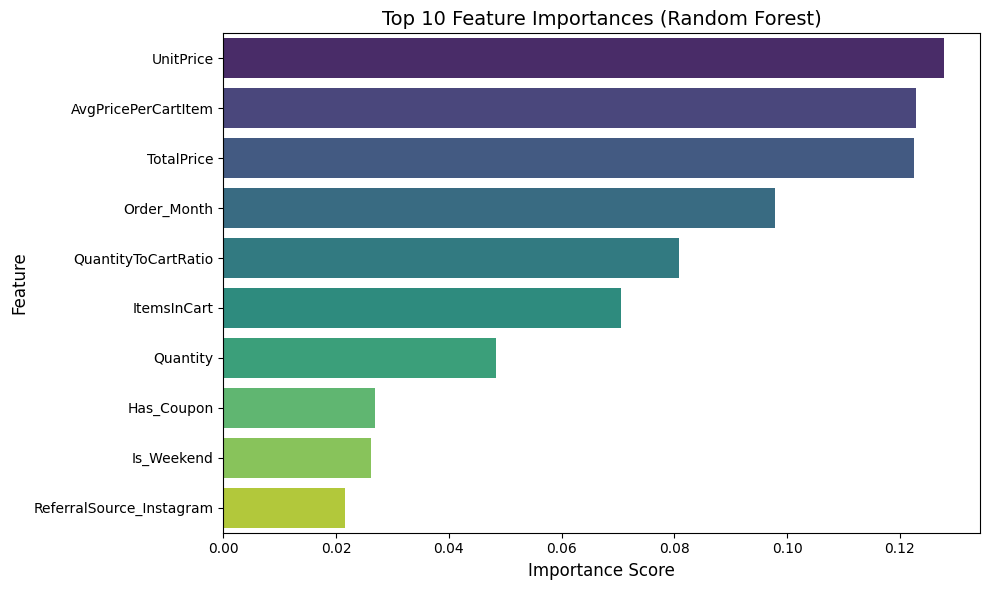

In [5]:
# =========================================================
# PROJECT 4: FEATURE IMPORTANCE & MODEL INTERPRETABILITY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACT FEATURE IMPORTANCES FROM PROJECT 3 MODEL
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- TOP 10 MOST IMPORTANT FEATURES ---")
print(feature_importance_df.head(10).to_string(index=False))

# 2. VISUALIZE FEATURE IMPORTANCE
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10),
    palette='viridis'
)
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Module 5: Hyperparameter Tuning & Model Comparison

In [6]:
# =========================================================
# MODULE 5: HYPERPARAMETER TUNING & MULTI-MODEL COMPARISON
# =========================================================
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. BASELINE MODEL: LOGISTIC REGRESSION
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_acc = log_reg.score(X_test, y_test)

# 2. HYPERPARAMETER TUNING FOR RANDOM FOREST
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
tuned_acc = best_rf.score(X_test, y_test)

print("--- MULTI-MODEL EVALUATION RESULTS ---")
print(f"📊 Logistic Regression Accuracy: {log_acc*100:.2f}%")
print(f"📊 Tuned Random Forest Accuracy: {tuned_acc*100:.2f}%")
print(f"⚙️ Best Parameters: {grid_search.best_params_}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- MULTI-MODEL EVALUATION RESULTS ---
📊 Logistic Regression Accuracy: 19.58%
📊 Tuned Random Forest Accuracy: 20.83%
⚙️ Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


#Interactive Gradio Web App

In [10]:
# =========================================================
# MODULE 6: INTERACTIVE DEMO APPLICATION (GRADIO)
# =========================================================
!pip install -q gradio
import gradio as gr
import pandas as pd
import numpy as np

# Extract exact feature column names directly from fitted estimators
reg_features = list(model.feature_names_in_)
cls_features = list(best_rf.feature_names_in_)

def predict_order_outcome(quantity, unit_price, items_in_cart, has_coupon, is_weekend):
    try:
        # Calculated engineered features
        total_price = quantity * unit_price
        avg_price = total_price / items_in_cart if items_in_cart > 0 else 0
        qty_ratio = quantity / items_in_cart if items_in_cart > 0 else 0

        # Helper function to construct aligned DataFrame
        def build_input_df(expected_features):
            df_in = pd.DataFrame(0, index=[0], columns=expected_features)
            if 'Quantity' in df_in.columns: df_in['Quantity'] = quantity
            if 'UnitPrice' in df_in.columns: df_in['UnitPrice'] = unit_price
            if 'ItemsInCart' in df_in.columns: df_in['ItemsInCart'] = items_in_cart
            if 'TotalPrice' in df_in.columns: df_in['TotalPrice'] = total_price
            if 'Has_Coupon' in df_in.columns: df_in['Has_Coupon'] = int(has_coupon)
            if 'Is_Weekend' in df_in.columns: df_in['Is_Weekend'] = int(is_weekend)
            if 'AvgPricePerCartItem' in df_in.columns: df_in['AvgPricePerCartItem'] = avg_price
            if 'QuantityToCartRatio' in df_in.columns: df_in['QuantityToCartRatio'] = qty_ratio
            return df_in

        # Create input matrices matching exact fitting features
        input_reg = build_input_df(reg_features)
        input_cls = build_input_df(cls_features)

        # Run model inference
        pred_price = model.predict(input_reg)[0]
        pred_status = best_rf.predict(input_cls)[0]

        return f"${pred_price:.2f}", str(pred_status)

    except Exception as e:
        return "Error in calculation", str(e)

# Build Gradio UI
demo = gr.Interface(
    fn=predict_order_outcome,
    inputs=[
        gr.Slider(1, 20, value=3, step=1, label="Quantity"),
        gr.Number(value=20.0, label="Unit Price ($)"),
        gr.Slider(1, 30, value=2, step=1, label="Items in Cart"),
        gr.Radio([0, 1], value=1, label="Has Coupon (0 = No, 1 = Yes)"),
        gr.Radio([0, 1], value=0, label="Is Weekend Order (0 = No, 1 = Yes)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Total Price ($)"),
        gr.Textbox(label="Predicted Order Status")
    ],
    title="DecodeLabs E-Commerce Order Predictor",
    description="Adjust input features to see real-time machine learning predictions."
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63134ace1a234e6032.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
